In [1]:
import pandas as pd
import sys
sys.path.append('../')
import FragShapley
import os
import numpy as np

/home/jannik/Documents/studies/phd/03_work/20_FragShapley/FragShapley/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Compare FragExplainer with SHAP

In [2]:
# load a dataframe of choice
fig_folder = "figures/"
df_expl = pd.read_pickle("../3_solubility/rf_regression_solubility/df_explanation.pkl")
dataset = 'esol_delaney'
split = 0 
df_expl = df_expl.query("dataset == @dataset")
df_expl['n_fragments'] = df_expl.fragExplainer_result.apply(len)

In [3]:
df_expl.columns

Index(['model', 'dataset', 'split', 'smiles', 'y_true', 'y_pred',
       'fragExplainer_result', 'fragExplainer_expected_value', 'shap_result',
       'shap_expected_value', 'atom_id_to_bits', 'frag_to_atom_ids',
       'n_fragments'],
      dtype='object')

## Visualize Some Compounds

In [4]:
# Visualize some compounds as an example
df_tmp = df_expl.query("n_fragments >= 3 and split == @split")

row_ids = [12, 16, 20, 23, 26, 39]

base_scale = 0.3

for row_id in row_ids:
    row = df_tmp.iloc[row_id]
    smiles = row.smiles
    fe_result = row.fragExplainer_result
    shap_result = row.shap_result
    atom_id_to_bits = row.atom_id_to_bits
    frag_to_atom_ids = row.frag_to_atom_ids

    # visualize fragExplainer result
    contributions_fE = FragShapley.visualization.get_atom_contribution_from_result_dict(smiles,
                                                                                        results_dict=fe_result,
                                                                                        frag_to_atom_ids=frag_to_atom_ids)
    out_fE = FragShapley.visualization.visualize_contributions(smiles=smiles,
                                                               contributions=contributions_fE,
                                                               scale=base_scale)
    with open(os.path.join(fig_folder, f"molecules_comparison/4_solubility_RF_fragExplainer_row_{row_id}.svg"), "w") as f:
        f.write(out_fE.data)
    
    # visualize SHAP results
    bits_to_atom_ids = FragShapley.visualization.get_bits_to_atom_ids(atom_id_to_bits)
    contributions_shap = FragShapley.visualization.get_atom_contribution_from_shap_results(atom_id_to_bits,
                                                                                           shap_result,
                                                                                           bits_to_atom_ids)
    # scale ratio
    scale_ratio = np.abs(contributions_fE).sum() / np.abs(contributions_shap).sum()

    out_SHAP = FragShapley.visualization.visualize_contributions(smiles=smiles,
                                                                 contributions=contributions_shap,
                                                                 scale=base_scale*scale_ratio)
    with open(os.path.join(fig_folder, f"molecules_comparison/4_solubility_RF_SHAP_row_{row_id}.svg"), "w") as f:
        f.write(out_SHAP.data)



## Compare Computational Demand

The cost to compute the exact Shapley Values requires $n_{\mathrm{frag}} 2^{n_\mathrm{frag}}$ inference steps



In [5]:
df_expl['n_inference_steps'] = df_expl.n_fragments.apply(lambda x: x * 2**x)

In [6]:
df_expl.n_inference_steps.describe()

count    1115.000000
mean       91.379372
std       405.866180
min         2.000000
25%         2.000000
50%         2.000000
75%        24.000000
max      4608.000000
Name: n_inference_steps, dtype: float64

When using a different represenation, the number of computations for the exact Shapley Values would rise to $n_{\mathrm{feat}} 2^{n_\mathrm{feat}}$ which is infesable for most moleculear representations which are often in the range of multiple hundreds of features.

## Most Contributing Features

In [7]:
# get a list of most contributing features in presence and absence
shap_matrix = np.vstack(df_expl.shap_result.to_list())

# need fingerprints to see which feature is active or not
from rdkit.Chem import rdFingerprintGenerator, MolFromSmiles
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
def SMILES_to_fingerprint(smiles):
    mol = MolFromSmiles(smiles)
    return mfpgen.GetFingerprintAsNumPy(mol)
df_expl['fp'] = df_expl.smiles.apply(SMILES_to_fingerprint)
fp_matrix = np.vstack(df_expl.fp.to_list())

In [8]:
# present features first
tmp_matrix = np.zeros(shap_matrix.shape)
tmp_matrix[fp_matrix == 1] = shap_matrix[fp_matrix == 1]
present_average = tmp_matrix.sum(0) / fp_matrix.sum(0) # error if bit is never on

/tmp/ipykernel_25163/3046767082.py:4: RuntimeWarning: invalid value encountered in divide
  present_average = tmp_matrix.sum(0) / fp_matrix.sum(0) # error if bit is never on


In [9]:
tmp_matrix = np.zeros(shap_matrix.shape)
tmp_matrix[fp_matrix == 0] = shap_matrix[fp_matrix == 0]
absent_average = tmp_matrix.sum(0) / (1. - fp_matrix).sum(0)

In [10]:
present_order_descending = np.argsort(present_average)[::-1]
absent_order_ascending = np.argsort(absent_average)

In [29]:
present_high = []

for idx in present_order_descending:
    if fp_matrix.sum(0)[int(idx)] >= 200:
        present_high.append(idx)
avg_contribution_present_high = present_average[np.array(present_high)]

In [30]:
present_high, avg_contribution_present_high

([np.int64(807),
  np.int64(650),
  np.int64(695),
  np.int64(1750),
  np.int64(314),
  np.int64(1088),
  np.int64(1917),
  np.int64(1057),
  np.int64(1199),
  np.int64(80),
  np.int64(294),
  np.int64(1873),
  np.int64(875),
  np.int64(1380),
  np.int64(1683)],
 array([ 0.1779903 ,  0.08055416,  0.02706887,  0.01258921,  0.01068157,
         0.00542262,  0.00440994, -0.00223842, -0.02110017, -0.03861418,
        -0.09656158, -0.11160938, -0.22031095, -0.32658785, -0.34426901]))

In [26]:
# try to visualize at least some features here

smiles = []
# get a list of molecules that contain the bit
for bit in present_high:
    for i, r in df_expl.iterrows():
        if r.fp[bit] == 1:
            smiles.append(r.smiles)
            break
# get molecules and their bitinfo
mols, aos = [], []
for s in smiles:
    mol = MolFromSmiles(s)
    mols.append(mol)
    ao = rdFingerprintGenerator.AdditionalOutput()
    ao.AllocateBitInfoMap()
    fp = mfpgen.GetFingerprint(mol, additionalOutput=ao)
    aos.append(ao)

In [31]:
tpls = [(mol, bit, ao.GetBitInfoMap()) for mol, bit, ao in zip(mols, present_high, aos)]
import rdkit.Chem.Draw as Draw
out = Draw.DrawMorganBits(tpls,
                          molsPerRow=3,
                          legends=[f"{v:+.3f}" for v in avg_contribution_present_high],
                          useSVG=True)

with open(os.path.join(fig_folder, f"4_solubility_RF_SHAP_bits.svg"), "w") as f:
        f.write(out.data)

In [32]:
smiles

['CCNC(=S)NCC',
 'CC12CCC(=O)C=C1CCC1C2CCC2(C)C1CCC2(C)O',
 'COc1ncc2nccnc2n1',
 'Cc1cccc(C)c1C',
 'CC12CCC(=O)C=C1CCC1C2CCC2(C)C1CCC2(C)O',
 'Cc1cccc(C)c1C',
 'CC(C)C(=O)C(C)C',
 'Cc1cccc(C)c1C',
 'Cc1ccc(C)c2ccccc12',
 'ClCC(Cl)Cl',
 'CCNC(=S)NCC',
 'Clc1cc(Cl)c(Cl)c(Cl)c1',
 'Clc1cc(Cl)c(Cl)c(Cl)c1',
 'Clc1cc(Cl)c(Cl)c(Cl)c1',
 'ClCC(Cl)Cl',
 'Clc1cc(Cl)c(Cl)c(Cl)c1']

## Graph of Alignment

In [16]:
# turn SHAP results in per fragment
def convert_shap_to_fragment_contribution(atom_id_to_bits,
                                          frag_to_atom_ids,
                                          shap_result):
    bits_to_atom_ids = FragShapley.visualization.get_bits_to_atom_ids(atom_id_to_bits)
    contributions_shap = FragShapley.visualization.get_atom_contribution_from_shap_results(atom_id_to_bits,
                                                                                           shap_result,
                                                                                           bits_to_atom_ids)
    

    contributions_shap_to_frag = np.zeros(len(frag_to_atom_ids.keys()))
    print(contributions_shap_to_frag)
    for atom_ids_frag in frag_to_atom_ids.values():
        for atom_id in atom_ids_frag:
            contributions_shap_to_frag[atom_id] = contributions_shap[np.array(atom_ids_frag)].mean()
    return contributions_shap_to_frag

In [17]:
from collections import defaultdict
def get_frag_dict_from_shap_result(frag_to_atom_ids,
                                   atom_id_to_bits,
                                   shap_result):
    bits_to_atom_ids = FragShapley.visualization.get_bits_to_atom_ids(atom_id_to_bits=atom_id_to_bits)

    shap_to_fE = defaultdict(float)
    for frag_id, atom_ids_frag in frag_to_atom_ids.items():
        # print(frag_id, atom_ids_frag)
        for atom_id in atom_ids_frag:
            for bit in atom_id_to_bits[atom_id]:
                # print(bit, len(bits_to_atom_ids[bit]))
                shap_to_fE[frag_id] += shap_result[bit] / len(bits_to_atom_ids[bit])
    return shap_to_fE

In [18]:
r = df_expl.iloc[0]

get_frag_dict_from_shap_result(atom_id_to_bits=r.atom_id_to_bits,
                               frag_to_atom_ids=r.frag_to_atom_ids,
                               shap_result=r.shap_result)

defaultdict(float, {0: np.float64(-0.2604367795156944)})

In [19]:
df_expl['SHAP_converted'] = df_expl.apply(lambda x: get_frag_dict_from_shap_result(atom_id_to_bits=x.atom_id_to_bits, 
                                                                                   frag_to_atom_ids=x.frag_to_atom_ids, 
                                                                                   shap_result=x.shap_result), axis=1)

In [20]:
fE_results = df_expl.fragExplainer_result.to_list()
shap_results = df_expl.SHAP_converted.to_list()

In [21]:
fE_flattened, shap_flattened = [], []

_ = [fE_flattened.extend(list(l.values())) for l in fE_results]
_ = [shap_flattened.extend(list(l.values())) for l in shap_results]

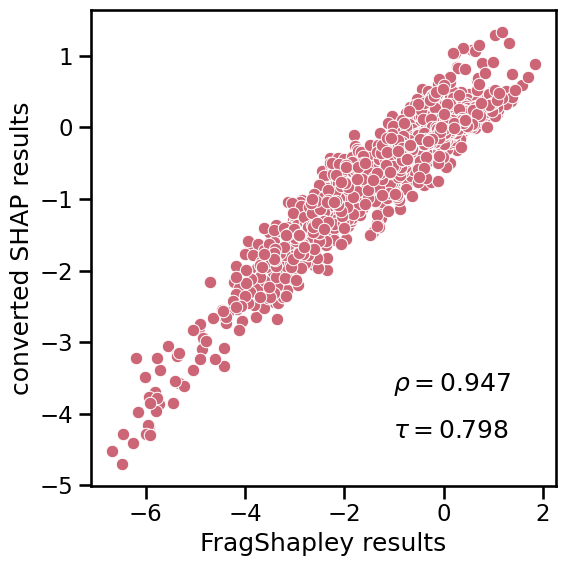

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, kendalltau, spearmanr

plt.style.use('style.mplstyle')
sns.set_context('talk', font_scale=1.0)

fig, axs = plt.subplots(1, 1, figsize=(6, 6))
sns.scatterplot(x=fE_flattened,
                y=shap_flattened,
                ax=axs)

axs.set_ylabel("converted SHAP results")
axs.set_xlabel("FragShapley results")

pearson = pearsonr(x=fE_flattened, y=shap_flattened)
spearman = spearmanr(fE_flattened, shap_flattened)
kendall = kendalltau(x=fE_flattened, y=shap_flattened)

axs.text(x=0.65, y=0.2,
         s=f"$\\rho = {pearson.statistic:.3f}$",
         transform=axs.transAxes)
axs.text(x=0.65, y=0.1,
         s=f"$\\tau = {kendall.statistic:.3f}$",
         transform=axs.transAxes)
fig.tight_layout()
fig.savefig(os.path.join(fig_folder, "x_solubility_FragExplainer_SHAP_alignment.pdf"))

In [23]:
spearman.pvalue, kendall.pvalue, pearson.pvalue

(np.float64(0.0), np.float64(0.0), np.float64(0.0))